## Problem Statement
- Predict whether a person has heart disease based on medical and lifestyle data.  
- Clean the dataset and find which features affect heart health.  
- Prepare the data for ML or statistical analysis.

## Dataset Summary
- **age** – patient age  
- **gender** – 1 = male, 2 = female  
- **height** – in cm  
- **weight** – in kg  
- **ap_hi** – systolic blood pressure  
- **ap_lo** – diastolic blood pressure  
- **cholesterol** – 1/2/3 levels  
- **gluc** – glucose level (1/2/3)  
- **smoke** – 0/1  
- **alco** – alcohol intake 0/1  
- **active** – physically active 0/1  
- **cardio** – target variable (1 = disease, 0 = no disease)

## Initial Observations
- BP values contain unrealistic numbers → needs fixing.  
- Height/weight show impossible values → must be clipped.  
- Categorical columns are numeric → need interpretation.  
- Target variable may be imbalanced.  
- Features like BP, cholesterol, glucose may show correlations.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("cardio_train.csv",sep=";")

In [7]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Dropping the id column

In [9]:
df.drop('id',axis=1,errors='ignore',inplace=True)

In [11]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Converting the age column from days to years.

In [ ]:
df['age'] = df['age']//365

In [13]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Getting the basic info about the dataset.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


Checking if there are null values present in the dataset.

In [17]:
df.isnull().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [19]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Adding a bmi column in the dataset.

In [22]:
df['bmi'] = df['weight']/(df['height']/100)**2

In [24]:
cols = list(df.columns)
i, j = cols.index('cardio'), cols.index('bmi')
cols[i], cols[j] = cols[j], cols[i]
cols

['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'bmi',
 'cardio']

In [26]:
df = df[cols]
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,21.967120,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,34.927679,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,23.507805,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,28.710479,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,23.011177,0


In [28]:
df['bmi'] = df['bmi'].clip(15,50)

There are some noisy values in ap_hi and ap_lo columns. We need to make those noisy data consistent(in range).

In [31]:
df['ap_hi'] = df['ap_hi'].clip(70,250)
df['ap_lo'] = df['ap_lo'].clip(40,150)

In [33]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,126.919157,82.277486,1.366871,1.226457,0.088129,0.053771,0.803729,27.490534,0.499700
std,2467.251667,0.476838,8.210126,14.395757,17.569508,12.501876,0.680250,0.572270,0.283484,0.225568,0.397179,5.226883,0.500003
min,10798.000000,1.000000,55.000000,10.000000,70.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,15.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,23.875115,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,26.374068,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,30.222222,1.000000
max,23713.000000,2.000000,250.000000,200.000000,250.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,50.000000,1.000000


Doing the same for height and weigth columns 

In [36]:
df['height'] = df['height'].clip(120,220)
df['weight'] = df['weight'].clip(30,200)

In [38]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.381857,74.206633,126.919157,82.277486,1.366871,1.226457,0.088129,0.053771,0.803729,27.490534,0.499700
std,2467.251667,0.476838,8.017616,14.392385,17.569508,12.501876,0.680250,0.572270,0.283484,0.225568,0.397179,5.226883,0.500003
min,10798.000000,1.000000,120.000000,30.000000,70.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,15.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,23.875115,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,26.374068,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,30.222222,1.000000
max,23713.000000,2.000000,220.000000,200.000000,250.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,50.000000,1.000000


In [40]:
df[df['ap_hi'] < df['ap_lo']]

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,cardio
260,18217,1,150,83.0,140,150,1,1,0,0,1,36.888889,1
345,18704,1,154,81.0,140,150,2,1,0,0,1,34.154158,1
474,19099,1,156,65.0,120,150,2,1,0,0,1,26.709402,0
567,21281,1,168,78.0,70,90,2,1,0,0,1,27.636054,1
613,18963,1,165,92.0,140,150,1,1,1,0,1,33.792470,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69480,17314,2,171,93.0,140,150,3,1,1,0,1,31.804658,1
69549,21243,1,155,69.0,70,90,1,3,0,0,1,28.720083,1
69552,22488,2,170,68.0,130,150,1,1,0,0,1,23.529412,0
69631,14674,1,154,90.0,130,150,2,2,0,0,1,37.949064,1


In [42]:
(df['ap_hi'] < df['ap_lo']).sum()

510

In [44]:
df.drop(df[df['ap_hi'] < df['ap_lo']].index, inplace = True)

In [46]:
(df['ap_hi'] < df['ap_lo']).sum()

0

In [48]:
df.drop_duplicates(inplace=True)

In [50]:
df.duplicated().sum()

0

In [52]:
corr = df.corr()

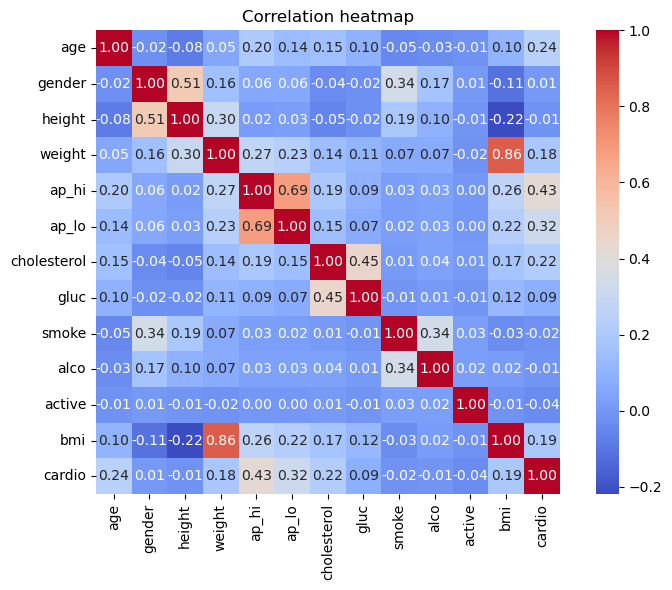

In [54]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [56]:
df.to_csv('cleaned.csv',index=False)

num_cols = ['age','weight','ap_hi','ap_lo','bmi']
for i in num_cols:
    sns.boxplot(x=df['cardio'],y=df[i])
    plt.title(i)
    plt.show()